In [4]:
import json

candidates = []

with open("F:\\autorecruit-\\data_forensic _files\\candidates.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        candidates.append(json.loads(line))

In [5]:
import json
from tqdm import tqdm

summaries = []

with open("F:\\autorecruit-\\data_forensic _files\\candidates.jsonl", "r") as f:

    for line in tqdm(f):

        candidate = json.loads(line)

        summaries.append(
            candidate["profile"]["summary"]
        )

print("Total summaries:", len(summaries))

100000it [00:04, 21158.42it/s]

Total summaries: 100000


**How many summaries are literally identical?**

In [6]:
from collections import Counter

summary_counter = Counter(summaries)


print("Unique summaries:",
      len(summary_counter))
print(summary_counter)

Unique summaries: 3241
Counter({"Professional with 7.5+ years of experience. I've spent my career in marketing manager roles, mostly focused on driving outcomes through process, people, and customer relationships. Lately I've been curious about how AI tools could augment my work — I've experimented with ChatGPT and a few other tools for productivity and content creation, and I think the space is exciting. Open to roles where I can apply my domain expertise alongside emerging AI capabilities.": 190, "Professional with 12.5+ years of experience. I've spent my career in marketing manager roles, mostly focused on driving outcomes through process, people, and customer relationships. Lately I've been curious about how AI tools could augment my work — I've experimented with ChatGPT and a few other tools for productivity and content creation, and I think the space is exciting. Open to roles where I can apply my domain expertise alongside emerging AI capabilities.": 189, "Professional with 4.8+

In [7]:
summaries

["Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid — Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side — Python, SQL, Spark, Airflow, warehouse design — and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice.",
 "Professional with 12.5+ years of experience. My professional background is in marketing manager — I've built and led teams, owned KPIs, and driven business outcomes in this domain. Lately I've been curious about how AI tools could augment my work — I've experimented with ChatGPT and a few other tools for productivity and content creation, and I think the sp

In [8]:
summary_counts = summary_counter.most_common()
summary_counts

[("Professional with 7.5+ years of experience. I've spent my career in marketing manager roles, mostly focused on driving outcomes through process, people, and customer relationships. Lately I've been curious about how AI tools could augment my work — I've experimented with ChatGPT and a few other tools for productivity and content creation, and I think the space is exciting. Open to roles where I can apply my domain expertise alongside emerging AI capabilities.",
  190),
 ("Professional with 12.5+ years of experience. I've spent my career in marketing manager roles, mostly focused on driving outcomes through process, people, and customer relationships. Lately I've been curious about how AI tools could augment my work — I've experimented with ChatGPT and a few other tools for productivity and content creation, and I think the space is exciting. Open to roles where I can apply my domain expertise alongside emerging AI capabilities.",
  189),
 ("Professional with 4.8+ years of experience

In [9]:
for summary, count in summary_counter.most_common(50):

    print("\nCOUNT:", count)

    print(summary[:])

    print("="*100)


COUNT: 190
Professional with 7.5+ years of experience. I've spent my career in marketing manager roles, mostly focused on driving outcomes through process, people, and customer relationships. Lately I've been curious about how AI tools could augment my work — I've experimented with ChatGPT and a few other tools for productivity and content creation, and I think the space is exciting. Open to roles where I can apply my domain expertise alongside emerging AI capabilities.

COUNT: 189
Professional with 12.5+ years of experience. I've spent my career in marketing manager roles, mostly focused on driving outcomes through process, people, and customer relationships. Lately I've been curious about how AI tools could augment my work — I've experimented with ChatGPT and a few other tools for productivity and content creation, and I think the space is exciting. Open to roles where I can apply my domain expertise alongside emerging AI capabilities.

COUNT: 183
Professional with 4.8+ years of exp

**Normalize Summaries**

In [10]:
import re

def normalize_summary(text):

    text = text.lower()

    text = re.sub(
        r'\d+(\.\d+)?',
        'NUMBER',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip()

normalized = [
    normalize_summary(s)
    for s in summaries
]
normalized[:20]

["software / data professional with NUMBER years of experience building data pipelines, backend systems, and analytics infrastructure. i'm a backend/data hybrid — spark, airflow, sql warehouses are home territory; i'm building competence on the ml side. my toolkit is solid on the data engineering side — python, sql, spark, airflow, warehouse design — and i've completed a couple of self-directed ml projects (kaggle competitions, side projects fine-tuning small models). interested in transitioning toward more ai/ml-focused work, ideally at a company where i can leverage my existing data-infra skills while learning modern ml practice.",
 "professional with NUMBER+ years of experience. my professional background is in marketing manager — i've built and led teams, owned kpis, and driven business outcomes in this domain. lately i've been curious about how ai tools could augment my work — i've experimented with chatgpt and a few other tools for productivity and content creation, and i think t

In [11]:
norm_counter = Counter(normalized)

print(
    "Unique normalized summaries:",
    len(norm_counter)
)

Unique normalized summaries: 76


**View Largest Templates**

In [12]:
norm_counter.most_common()

[("professional with NUMBER+ years of experience. i'm a marketing manager with substantial experience in cross-functional collaboration, stakeholder management, and execution. lately i've been curious about how ai tools could augment my work — i've experimented with chatgpt and a few other tools for productivity and content creation, and i think the space is exciting. open to roles where i can apply my domain expertise alongside emerging ai capabilities.",
  21316),
 ("professional with NUMBER+ years of experience. i've spent my career in marketing manager roles, mostly focused on driving outcomes through process, people, and customer relationships. lately i've been curious about how ai tools could augment my work — i've experimented with chatgpt and a few other tools for productivity and content creation, and i think the space is exciting. open to roles where i can apply my domain expertise alongside emerging ai capabilities.",
  21090),
 ("professional with NUMBER+ years of experienc

In [13]:
lengths = [
    len(s.split())
    for s in summaries
]

length_counter = Counter(lengths)
length_counter

Counter({68: 21316,
         73: 21090,
         76: 20898,
         98: 7503,
         101: 7468,
         99: 6308,
         104: 6233,
         118: 5049,
         93: 1251,
         95: 1237,
         117: 493,
         88: 267,
         92: 257,
         96: 252,
         86: 224,
         112: 38,
         115: 26,
         111: 17,
         116: 15,
         110: 11,
         130: 10,
         106: 8,
         113: 5,
         107: 5,
         135: 5,
         132: 4,
         134: 3,
         133: 3,
         145: 1,
         137: 1,
         136: 1,
         147: 1})

In [14]:
import numpy as np

print("Min:", np.min(lengths))
print("Mean:", np.mean(lengths))
print("Median:", np.median(lengths))
print("Max:", np.max(lengths))

Min: 68
Mean: 83.35409
Median: 76.0
Max: 147


In [15]:
import pandas as pd
pd.Series(normalized)\
.value_counts()\
.head(50)

professional with NUMBER+ years of experience. i'm a marketing manager with substantial experience in cross-functional collaboration, stakeholder management, and execution. lately i've been curious about how ai tools could augment my work — i've experimented with chatgpt and a few other tools for productivity and content creation, and i think the space is exciting. open to roles where i can apply my domain expertise alongside emerging ai capabilities.                                                                                                                                                                                                                                                                                                                                                                                           21316
professional with NUMBER+ years of experience. i've spent my career in marketing manager roles, mostly focused on driving outcomes through process, people, and 

****step 2.2****

In [16]:
descriptions = []

for c in candidates:

    for job in c["career_history"]:

        descriptions.append(
            job["description"]
        )

print(
    "Total descriptions:",
    len(descriptions)
)

Total descriptions: 300171


In [17]:
from collections import Counter

desc_counter = Counter(
    descriptions
)

print(
    "Unique descriptions:",
    len(desc_counter)
)

total = len(descriptions)

unique = len(desc_counter)

print(
    "Reuse Ratio:",
    round(
        unique/total,
        4
    )
)

Unique descriptions: 44
Reuse Ratio: 0.0001


In [18]:
for desc, count in desc_counter.most_common(50):

    print("\nCOUNT:", count)

    print(desc[:700])

    print("="*120)


COUNT: 25515
Enterprise sales of cloud software solutions into the mid-market segment. Carried a $1.8M ARR quota and consistently delivered against it across the last three years. Owned the full sales cycle: prospecting, discovery, technical evaluation (with SE support), commercial negotiation, and close. Strong on consultative selling for technical buyers; comfortable engaging with both engineering and finance stakeholders.

COUNT: 25290
Customer support team lead at a SaaS product. Managed a team of 8 support agents handling tier-1 and tier-2 tickets; owned the escalation process to engineering and the customer-feedback loop to product. Built out the support knowledge base and the agent training program. Strong on the people-management side and the process side; lighter on technical depth beyond product expertise.

COUNT: 25237
Marketing leadership role at a B2B SaaS company. Owned the demand-generation function — content marketing, paid acquisition, SEO, email nurture. Built and ma

In [19]:
import re

def normalize_desc(text):

    text = text.lower()

    text = re.sub(
        r'\d+(\.\d+)?',
        'NUMBER',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip()

normalized_desc = [
    normalize_desc(d)
    for d in descriptions
]

In [20]:
normalized_desc

['implemented streaming data pipelines on kafka and spark streaming for a real-time user-activity processing platform. designed the schema-registry integration, the watermark/state management approach, and the deduplication logic for late-arriving events. worked closely with the data science team to make sure feature pipelines aligned with what their models needed. most of my career has been data engineering, with some adjacent ml exposure.',
 'built and maintained data pipelines on apache airflow processing ~NUMBERgb of daily transactional data across NUMBER source systems. worked extensively with spark (pyspark) for batch processing and dbt for the transformation/modeling layer in our snowflake warehouse. owned the on-call rotation for data quality issues — wrote most of the data quality checks that detect schema drift and unusual volume changes. the pipeline supports the analytics team and a few internal ml models.',
 'customer support team lead at a saas product. managed a team of 

In [21]:
norm_counter = Counter(
    normalized_desc
)

print(
    "Normalized Templates:",
    len(norm_counter)
)

Normalized Templates: 44


In [22]:
for desc, count in norm_counter.most_common():

    print(count)
    print(desc[:500])

25515
enterprise sales of cloud software solutions into the mid-market segment. carried a $NUMBERm arr quota and consistently delivered against it across the last three years. owned the full sales cycle: prospecting, discovery, technical evaluation (with se support), commercial negotiation, and close. strong on consultative selling for technical buyers; comfortable engaging with both engineering and finance stakeholders.
25290
customer support team lead at a saas product. managed a team of NUMBER support agents handling tier-NUMBER and tier-NUMBER tickets; owned the escalation process to engineering and the customer-feedback loop to product. built out the support knowledge base and the agent training program. strong on the people-management side and the process side; lighter on technical depth beyond product expertise.
25237
marketing leadership role at a bNUMBERb saas company. owned the demand-generation function — content marketing, paid acquisition, seo, email nurture. built and man

In [23]:
lengths = [
    len(d.split())
    for d in descriptions
]

lengths
import numpy as np

print(np.mean(lengths))
print(np.median(lengths))
print(np.min(lengths))
print(np.max(lengths))

56.04326533875691
56.0
44
85


***step 2.3***

In [24]:
import pandas as pd

rows = []

for c in candidates:

    cid = c["candidate_id"]

    for skill in c["skills"]:

        rows.append({
            "candidate_id": cid,
            "skill": skill["name"]
        })

skills_df = pd.DataFrame(rows)
skills_df


,candidate_id,skill
0,CAND_0000001,Tailwind
1,CAND_0000001,NLP
2,CAND_0000001,Image Classification
3,CAND_0000001,Fine-tuning LLMs
4,CAND_0000001,Weights & Biases
...,...,...
960297,CAND_0100000,Photoshop
960298,CAND_0100000,Agile
960299,CAND_0100000,Salesforce CRM
960300,CAND_0100000,Databricks


In [25]:
skill_matrix = pd.crosstab(
    skills_df["candidate_id"],
    skills_df["skill"]
)
skill_matrix

skill,ASR,AWS,Accounting,Agile,Airflow,Angular,Apache Beam,Apache Flink,Azure,BM25,...,Vue.js,Weaviate,Webpack,Weights & Biases,Workflow Orchestration,YOLO,dbt,gRPC,pgvector,scikit-learn
candidate_id,,,,,,,,,,,,,,,,,,,,,
CAND_0000001,0,1,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
CAND_0000002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CAND_0000003,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CAND_0000004,0,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
CAND_0000005,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CAND_0099996,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CAND_0099997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
CAND_0099998,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
corr_matrix = skill_matrix.corr()
corr_matrix

skill,ASR,AWS,Accounting,Agile,Airflow,Angular,Apache Beam,Apache Flink,Azure,BM25,...,Vue.js,Weaviate,Webpack,Weights & Biases,Workflow Orchestration,YOLO,dbt,gRPC,pgvector,scikit-learn
skill,,,,,,,,,,,,,,,,,,,,,
ASR,1.000000,-0.006108,-0.003453,-0.008323,-0.007407,-0.006423,-0.007213,-0.001667,-0.005558,0.057702,...,-0.006648,0.048220,-0.004148,0.042041,0.007323,0.047829,-0.007304,-0.005991,0.064418,0.056212
AWS,-0.006108,1.000000,-0.003468,-0.007682,-0.001992,-0.010353,-0.005369,-0.011376,-0.003196,-0.008214,...,-0.005882,-0.005534,-0.003924,-0.006539,-0.002033,-0.008620,0.001126,-0.007869,-0.006467,-0.007858
Accounting,-0.003453,-0.003468,1.000000,-0.002880,-0.004982,-0.005555,-0.004315,-0.001626,-0.008103,-0.012518,...,-0.005584,-0.004336,-0.003905,-0.009068,-0.002036,-0.005687,-0.002719,-0.008221,-0.002919,-0.005788
Agile,-0.008323,-0.007682,-0.002880,1.000000,-0.004971,-0.004889,-0.008160,-0.003313,0.001581,-0.001234,...,-0.011198,-0.000930,-0.006530,-0.004569,-0.002036,-0.001966,-0.002614,-0.000753,-0.005266,-0.005785
Airflow,-0.007407,-0.001992,-0.004982,-0.004971,1.000000,-0.004645,-0.005192,-0.006663,-0.005105,-0.012681,...,-0.004861,-0.004751,-0.003087,-0.006691,-0.002033,-0.004478,-0.006891,-0.008352,-0.007255,-0.007317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YOLO,0.047829,-0.008620,-0.005687,-0.001966,-0.004478,-0.005506,-0.003417,-0.005926,-0.004614,0.045676,...,-0.004299,0.047420,-0.005378,0.048982,-0.001234,1.000000,-0.000926,-0.003331,0.053608,0.066546
dbt,-0.007304,0.001126,-0.002719,-0.002614,-0.006891,-0.003980,-0.008966,-0.005346,-0.002074,-0.006967,...,-0.007490,-0.003496,-0.012246,-0.005285,-0.002027,-0.000926,1.000000,-0.004956,-0.004696,-0.006308
gRPC,-0.005991,-0.007869,-0.008221,-0.000753,-0.008352,0.002590,-0.003057,-0.004637,-0.007852,-0.004289,...,-0.009231,-0.007922,-0.008049,-0.007611,-0.002019,-0.003331,-0.004956,1.000000,-0.009380,-0.010388


In [27]:
from mlxtend.frequent_patterns \
    import apriori


frequent = apriori(
    skill_matrix.astype(bool),
    min_support=0.01,
    use_colnames=True
)

In [28]:
frequent.sort_values(
    "support",
    ascending=False
)

,support,itemsets
39,0.12246,frozenset({HTML})
19,0.12244,frozenset({Databricks})
85,0.12222,frozenset({Redux})
106,0.12187,frozenset({Terraform})
5,0.12173,frozenset({Angular})
...,...,...
3015,0.01089,"frozenset({FAISS, RAG, Prompt Engineering, Sen..."
3028,0.01088,"frozenset({FAISS, Vector Search, RAG, Sentence..."
2937,0.01086,"frozenset({FAISS, Information Retrieval, Promp..."
2860,0.01083,"frozenset({FAISS, Fine-tuning LLMs, RAG, Sente..."


In [34]:
frequent[
    frequent["itemsets"]
    .apply(lambda x: len(x) >= 3)
] \
.sort_values(
    "support",
    ascending=False
) \
.head(50)

,support,itemsets
2378,0.01781,"frozenset({Hugging Face Transformers, Vector S..."
2405,0.01780,"frozenset({Hugging Face Transformers, Vector S..."
2471,0.01779,"frozenset({Pinecone, LangChain, Prompt Enginee..."
2487,0.01774,"frozenset({Recommendation Systems, LangChain, ..."
2413,0.01770,"frozenset({Information Retrieval, LLMs, Senten..."
2489,0.01768,"frozenset({Semantic Search, LangChain, Sentenc..."
2187,0.01768,"frozenset({Hugging Face Transformers, LLMs, Em..."
2262,0.01764,"frozenset({FAISS, Information Retrieval, LLMs})"
2414,0.01764,"frozenset({Vector Search, Information Retrieva..."
2475,0.01763,"frozenset({Pinecone, LangChain, Sentence Trans..."


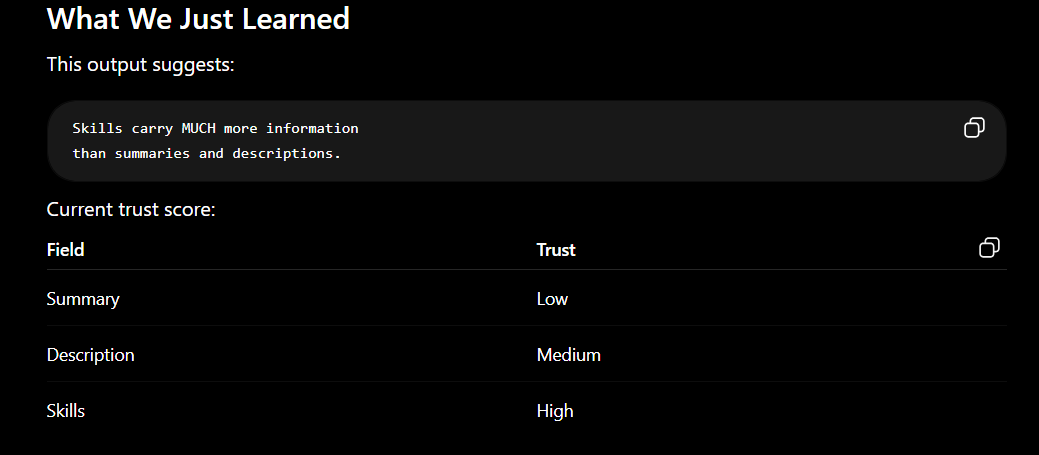

In [41]:
frequent_3 = frequent[
    frequent["itemsets"].apply(
        lambda x: len(x) >= 3
    )
].copy()

frequent_3["bundle"] = (
    frequent_3["itemsets"]
    .apply(lambda x: ", ".join(sorted(list(x))))
)

frequent_3 = frequent_3.sort_values(
    "support",
    ascending=False
)

frequent_3_df = pd.DataFrame({
    "support": frequent_3["support"],
    "bundle": frequent_3["bundle"],})

frequent_3_df[ "bundle" ]
frequent_3_df.to_csv("frequent_skill_bundles.csv", index=False)

In [42]:
unique_skills = skills_df["skill"].nunique()

print(unique_skills)

133


In [53]:
skills_df["skill"].value_counts().head(60)
skills_df["skill"].value_counts().to_csv("skill_frequencies.csv", index=True)

In [54]:
skills_per_candidate = (
    skills_df.groupby("candidate_id")
             .size()
)

print(skills_per_candidate.describe())

count    100000.00000
mean          9.60302
std           3.31163
min           5.00000
25%           7.00000
50%           9.00000
75%          11.00000
max          23.00000
dtype: float64


In [56]:
skills_df.groupby("candidate_id")["skill"] \
         .apply(list) \
         .head(20).to_csv("candidate_skills_2.csv", index=True)

step 2.4 reverse engineer the templates